# Preprocessing

## Objective
In this notebook, we prepare the MRI dataset for deep learning using PyTorch.  
The goal is to transform raw MRI images into a clean, normalized, and model-ready dataset.

## Steps covered:
- Load dataset paths
- Understand class distribution
- Handle image resizing
- Normalize images
- Apply data augmentation (for training only)
- Create PyTorch Dataset & DataLoader

## 1) Import Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image

## 2) Dataset Path
We check the dataset folders and classes to understand the problem.

In [ ]:
DATA_PATH = r"..\data\raw"
TRAIN_PATH = os.path.join(DATA_PATH, "train")
TEST_PATH = os.path.join(DATA_PATH, "test")

classes = os.listdir(TRAIN_PATH)
print(f"Classes: {classes}")

In [6]:
for c in classes:
    path = os.path.join(TRAIN_PATH, c)
    print(f"{c}: {len(os.listdir(path))}")

glioma: 1147
meningioma: 1329
no_tumor: 1067
pituitary: 1457


## 3) Show Samples
We display sample MRI images from each class to understand the data quality.

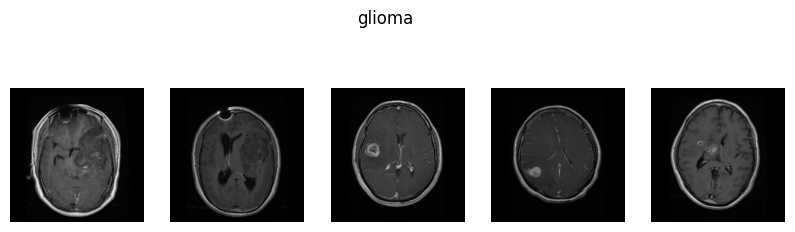

In [9]:
def show_samples(class_name):
    path = os.path.join(TRAIN_PATH, class_name)
    images = os.listdir(path)[:5]

    plt.figure(figsize=(10,3))

    for i, img_name in enumerate(images):
        img_path = os.path.join(path, img_name)
        img = Image.open(img_path)

        plt.subplot(1,5,i+1)
        plt.imshow(img, cmap='gray')
        plt.axis('off')

    plt.suptitle(class_name)
    plt.show()

show_samples("glioma")

## 4) Image Preprocessing & Augmentation

We prepare images for training by:
- Resizing images to fixed size (224x224)
- Converting images to tensors
- Normalizing pixel values
- Applying data augmentation (training only)

In [ ]:
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])